----

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st

# Cargar datasets
df_companies = pd.read_csv('../data/project_sql_result_01.csv')
df_neighborhoods = pd.read_csv('../data/project_sql_result_04.csv')
df_trips = pd.read_csv('../data/project_sql_result_07.csv')

# Vista rápida
df_companies.info()
df_neighborhoods.info()
df_trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_se

In [2]:
top10_neighborhoods = df_neighborhoods.sort_values(by='average_trips', ascending=False).head(10)
print(top10_neighborhoods) # Se mostraron los 10 vecindarios de viajes

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


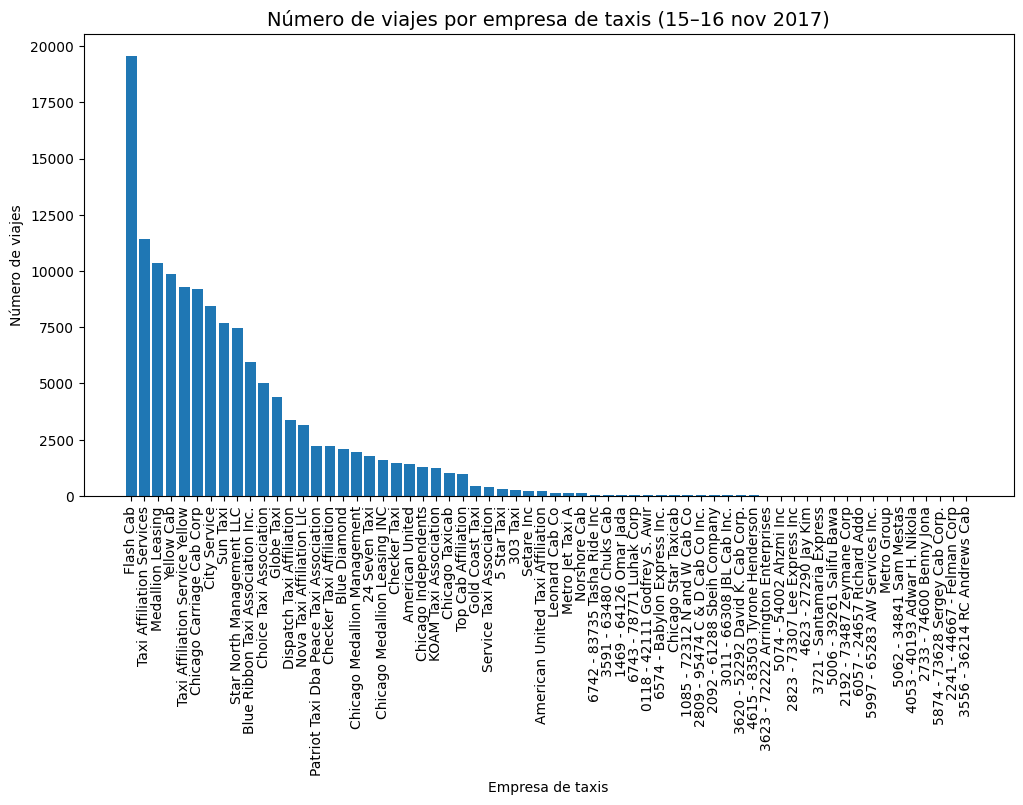

In [3]:
plt.figure(figsize=(12,6))
plt.bar(df_companies['company_name'], df_companies['trips_amount'])
plt.title('Número de viajes por empresa de taxis (15–16 nov 2017)', fontsize=14)
plt.xlabel('Empresa de taxis')
plt.ylabel('Número de viajes')
plt.xticks(rotation=90)
plt.show()

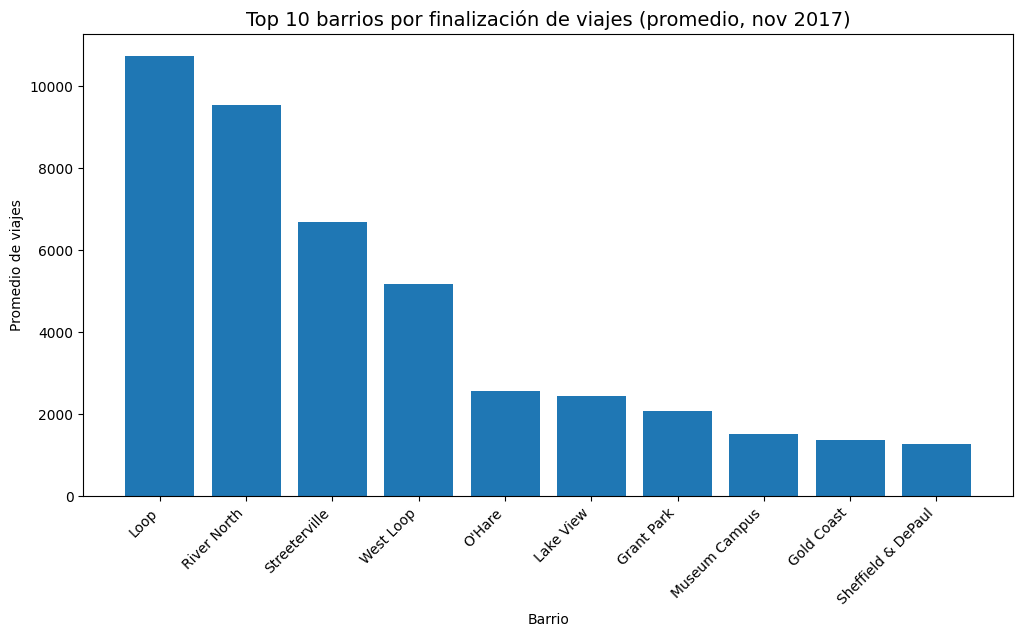

In [4]:
plt.figure(figsize=(12,6))
plt.bar(top10_neighborhoods['dropoff_location_name'], top10_neighborhoods['average_trips'])
plt.title('Top 10 barrios por finalización de viajes (promedio, nov 2017)', fontsize=14)
plt.xlabel('Barrio')
plt.ylabel('Promedio de viajes')
plt.xticks(rotation=45, ha='right')
plt.show()

In [5]:
df_trips['weather_conditions'].value_counts() # Contamos cuantos dias hay Buenos y Malos

Good    888
Bad     180
Name: weather_conditions, dtype: int64

In [6]:
df_trips['start_ts'] = pd.to_datetime(df_trips['start_ts'], errors='coerce') # Cambiamos a Formato fecha

In [7]:
df_trips.info() # verificamos el cambio a formato fecha

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.2+ KB


In [8]:
df_trips['weekday'] = df_trips['start_ts'].dt.dayofweek # S extrae el dia miercoles

In [9]:
df_sat = df_trips[df_trips['weekday'] == 5] # Filtramos dia Sabado

In [10]:
sat_bad = df_sat.loc[df_sat['weather_conditions'] == 'Bad', 'duration_seconds'] # Separamos dias malos
sat_good = df_sat.loc[df_sat['weather_conditions'] == 'Good', 'duration_seconds'] # Separamos dias buenos

In [11]:
alpha = 0.05

# Verificar igualdad de varianzas
levene_test = st.levene(sat_bad, sat_good)
print("p-value Levene:", levene_test.pvalue)

# t-test (con asunción de varianzas iguales/no iguales según Levene)
results = st.ttest_ind(sat_bad, sat_good, equal_var=False)
print("p-value t-test:", results.pvalue)

p-value Levene: 0.5332038671974493
p-value t-test: 6.738994326108734e-12


Hipótesis nula (H0): La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O’Hare los sábados es la misma bajo condiciones climáticas normales (Good) y bajo condiciones lluviosas (Bad), Hipótesis alternativa (H1): La duración promedio de los viajes desde el Loop hasta O’Hare los sábados es diferente bajo condiciones de lluvia, se usaron 2 muestras independientes: viajes de sábado con clima Bad (lluvia o tormenta), viajes de sábado con clima Good (resto de condiciones), usamos la prueba de Levene para comprobar si las varianzas de los dos grupos pueden considerarse iguales, Se tomó alpha = 0.05 como valor estándar en estudios exploratorios